In [1]:
# 1. import
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.cluster import DBSCAN

In [2]:
#2. initial
spark = SparkSession.builder \
    .appName("NYC Crime Hot Zones") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/28 23:23:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
#3. read
input_path = "Sample2-NYPD_Complaint_Data_Historic - Copy.csv"
df = spark.read.csv(
    input_path,
    header=True,
    inferSchema=True
)
print("Schema and example：")
df.printSchema()
df.show(5, truncate=False)

Schema and example：
root
 |-- CMPLNT_NUM: string (nullable = true)
 |-- CMPLNT_FR_DT: string (nullable = true)
 |-- CMPLNT_FR_TM: timestamp (nullable = true)
 |-- CMPLNT_TO_DT: string (nullable = true)
 |-- CMPLNT_TO_TM: string (nullable = true)
 |-- ADDR_PCT_CD: integer (nullable = true)
 |-- RPT_DT: string (nullable = true)
 |-- KY_CD: integer (nullable = true)
 |-- OFNS_DESC: string (nullable = true)
 |-- PD_CD: integer (nullable = true)
 |-- PD_DESC: string (nullable = true)
 |-- CRM_ATPT_CPTD_CD: string (nullable = true)
 |-- LAW_CAT_CD: string (nullable = true)
 |-- BORO_NM: string (nullable = true)
 |-- LOC_OF_OCCUR_DESC: string (nullable = true)
 |-- PREM_TYP_DESC: string (nullable = true)
 |-- JURIS_DESC: string (nullable = true)
 |-- JURISDICTION_CODE: integer (nullable = true)
 |-- PARKS_NM: string (nullable = true)
 |-- HADEVELOPT: string (nullable = true)
 |-- HOUSING_PSA: string (nullable = true)
 |-- X_COORD_CD: integer (nullable = true)
 |-- Y_COORD_CD: integer (nullabl

25/04/28 23:24:35 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------+------------+-------------------+------------+------------+-----------+----------+-----+------------------------------+-----+-------------------------------------------------------------+----------------+-----------+-------------+-----------------+----------------------+----------------+-----------------+--------+----------+-----------+----------+----------+--------------+---------+--------+----------------+---------+----------+-----------------------+-------------------------+------------+-------------+------------------------+-------+
|CMPLNT_NUM|CMPLNT_FR_DT|CMPLNT_FR_TM       |CMPLNT_TO_DT|CMPLNT_TO_TM|ADDR_PCT_CD|RPT_DT    |KY_CD|OFNS_DESC                     |PD_CD|PD_DESC                                                      |CRM_ATPT_CPTD_CD|LAW_CAT_CD |BORO_NM      |LOC_OF_OCCUR_DESC|PREM_TYP_DESC         |JURIS_DESC      |JURISDICTION_CODE|PARKS_NM|HADEVELOPT|HOUSING_PSA|X_COORD_CD|Y_COORD_CD|SUSP_AGE_GROUP|SUSP_RACE|SUSP_SEX|TRANSIT_DISTRICT|Latitude |Longitude |L

In [4]:
# 4. filter
df2 = (
    df
    .filter(col("Latitude").isNotNull() & col("Longitude").isNotNull())
    .withColumn("lat", col("Latitude").cast("double"))
    .withColumn("lon", col("Longitude").cast("double"))
)

In [5]:
# 5.sample to pandas
sample_pd = df2.sample(fraction=0.02, seed=42).toPandas()
print(f"Data volume after sampling：{len(sample_pd)}")

Data volume after sampling：30587


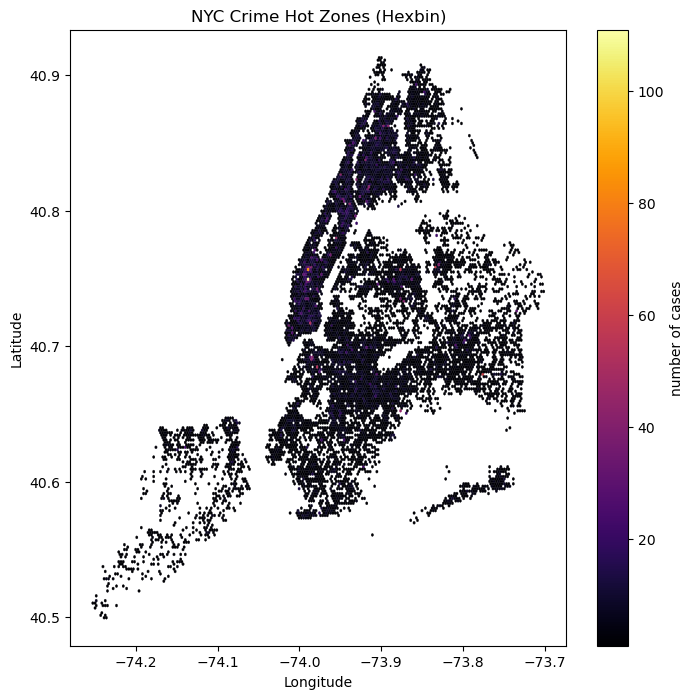

In [6]:
# 6. Hexbin
plt.figure(figsize=(8,8))
hb = plt.hexbin(
    sample_pd["lon"],
    sample_pd["lat"],
    gridsize=200,
    mincnt=1,
    cmap="inferno",
    linewidths=0.2
)
plt.colorbar(hb, label="number of cases")
plt.title("NYC Crime Hot Zones (Hexbin)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

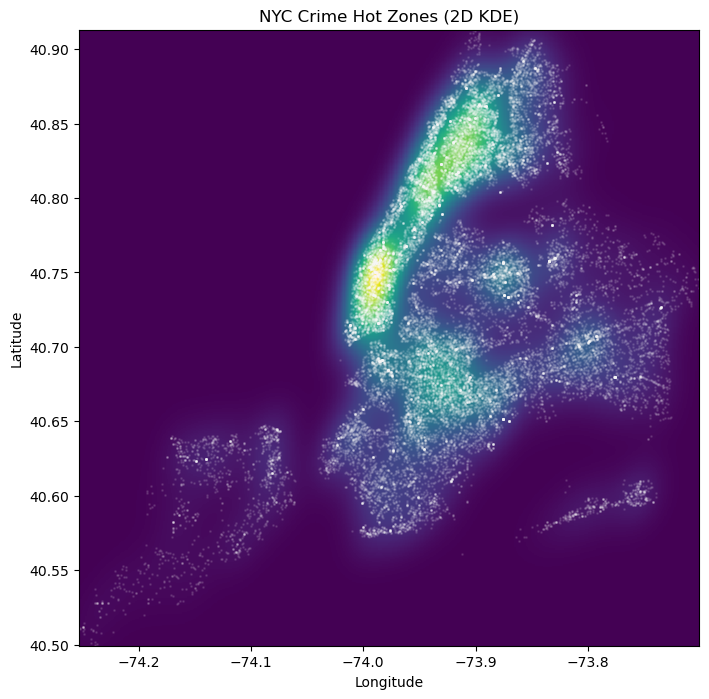

In [7]:
# 7.2D KDE
coords = np.vstack([sample_pd["lon"], sample_pd["lat"]])
kde = gaussian_kde(coords)

lon_min, lon_max = sample_pd["lon"].min(), sample_pd["lon"].max()
lat_min, lat_max = sample_pd["lat"].min(), sample_pd["lat"].max()
xi, yi = np.mgrid[lon_min:lon_max:500j, lat_min:lat_max:500j]
zi = kde(np.vstack([xi.flatten(), yi.flatten()])).reshape(xi.shape)

plt.figure(figsize=(8,8))
plt.pcolormesh(xi, yi, zi, shading="auto")
plt.scatter(sample_pd["lon"], sample_pd["lat"], s=1, alpha=0.1, color="white")
plt.title("NYC Crime Hot Zones (2D KDE)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

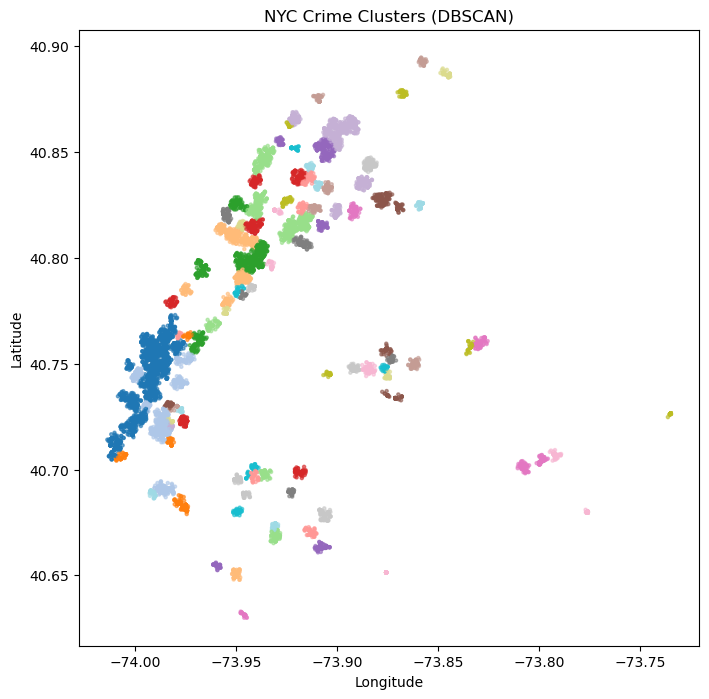

In [8]:
# 8. DBSCAN clustering lable
coords_arr = sample_pd[["lon","lat"]].values
db = DBSCAN(eps=0.002, min_samples=30).fit(coords_arr)
sample_pd["cluster"] = db.labels_

# Only display the points that are clustered (label ≥ 0)
core = sample_pd[sample_pd["cluster"] >= 0]

plt.figure(figsize=(8,8))
plt.scatter(
    core["lon"], core["lat"],
    c=core["cluster"], cmap="tab20",
    s=5, alpha=0.6
)
plt.title("NYC Crime Clusters (DBSCAN)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

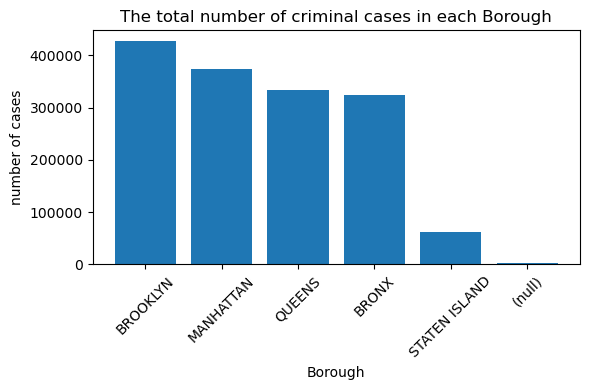

In [9]:
# 9. Borough Bar chart of total crime count
by_boro = (
    df.groupBy("BORO_NM")
      .count()
      .orderBy("count", ascending=False)
      .toPandas()
)

plt.figure(figsize=(6,4))
plt.bar(by_boro["BORO_NM"], by_boro["count"])
plt.xticks(rotation=45)
plt.title("The total number of criminal cases in each Borough")
plt.xlabel("Borough")
plt.ylabel("number of cases")
plt.tight_layout()
plt.show()

In [15]:
from pyspark.sql.functions import col, year as spark_year

df_yb = (
    df2
    .withColumn("year", spark_year(col("RPT_DT")))
    .groupBy("year", "BORO_NM")
    .count()
    .orderBy("year", "BORO_NM")
)
pdf_yb = df_yb.toPandas()


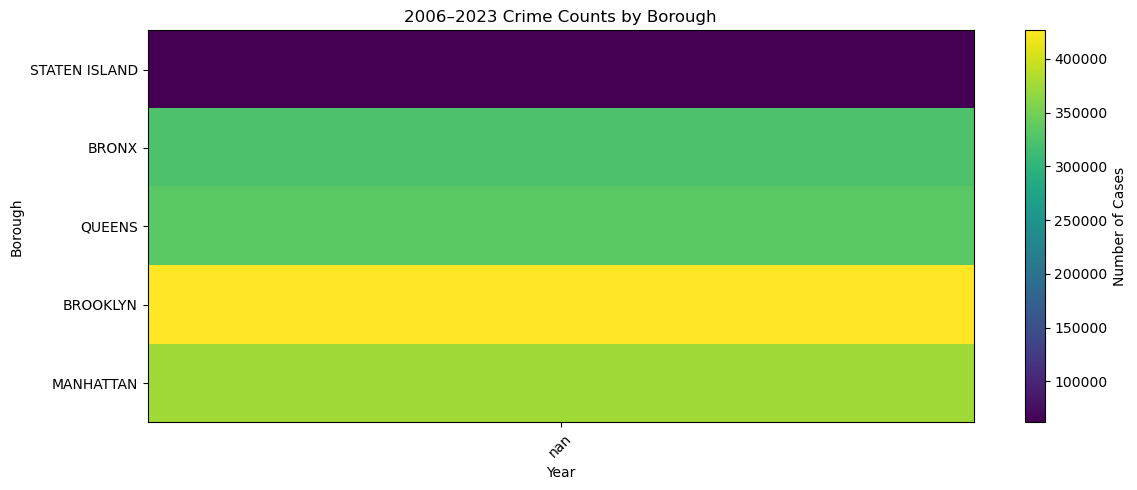

In [16]:
import matplotlib.pyplot as plt

# Pivot the DataFrame to get boroughs as rows and years as columns
heat_df = pdf_yb.pivot(
    index='BORO_NM', 
    columns='year', 
    values='count'
).reindex(['MANHATTAN', 'BROOKLYN', 'QUEENS', 'BRONX', 'STATEN ISLAND'])

plt.figure(figsize=(12, 5))
# Display the heatmap matrix
plt.imshow(heat_df, aspect='auto', origin='lower')
plt.colorbar(label='Number of Cases')
plt.xticks(range(len(heat_df.columns)), heat_df.columns, rotation=45)
plt.yticks(range(len(heat_df.index)), heat_df.index)
plt.title('2006–2023 Crime Counts by Borough')
plt.xlabel('Year')
plt.ylabel('Borough')
plt.tight_layout()
plt.show()



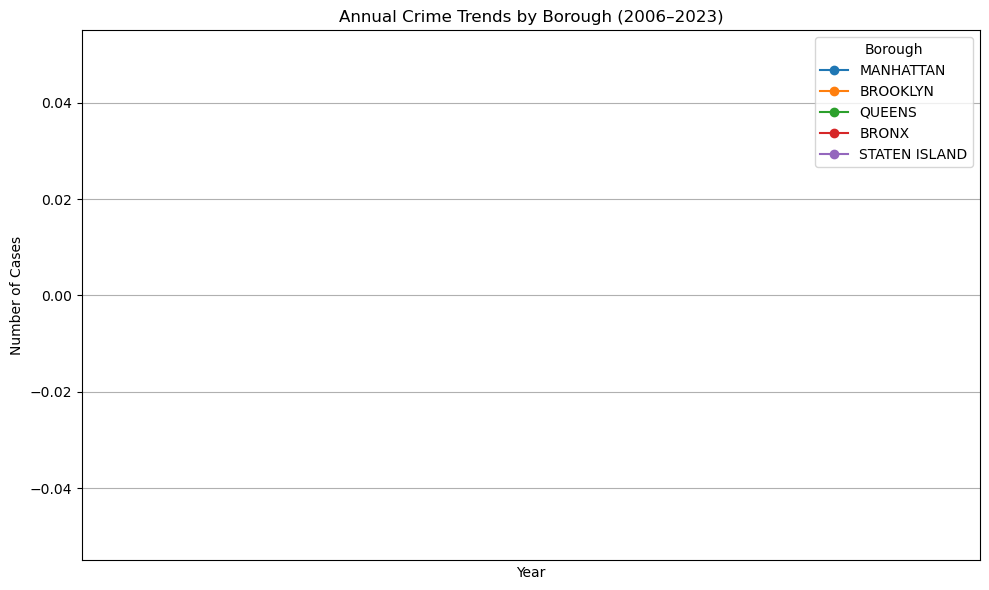

In [20]:
# 重新准备 heat_df：pivot 并剔除全 NaN 列和列名为 NaN 的那一列
heat_df = pdf_yb.pivot(
    index='BORO_NM',
    columns='year',
    values='count'
).reindex(['MANHATTAN','BROOKLYN','QUEENS','BRONX','STATEN ISLAND'])

# Drop any columns where the column name is NaN or the entire column is NaN
heat_df = heat_df.loc[:, heat_df.columns.notna()]      # remove NaN-year column
heat_df = heat_df.dropna(axis=1, how='all')            # remove all-empty columns

# Now cast column names (years) to int safely
years = heat_df.columns.astype(int)

# Plot the lines
plt.figure(figsize=(10, 6))
for borough in heat_df.index:
    plt.plot(
        years,                              # x-values: integer years
        heat_df.loc[borough].fillna(0),    # y-values: counts (fill missing with 0)
        marker='o',
        label=borough
    )

# Chart decoration
plt.title('Annual Crime Trends by Borough (2006–2023)')
plt.xlabel('Year')
plt.ylabel('Number of Cases')
plt.xticks(years, rotation=45)
plt.legend(title='Borough')
plt.grid(True)
plt.tight_layout()
plt.show()


In [21]:
from pyspark.sql.functions import to_date

# 1. Ensure RPT_DT is DateType
df2 = df2.withColumn("RPT_DT", to_date(col("RPT_DT"), "MM/dd/yyyy"))

# 2. Filter for a year and convert
target_year = 2023
year_df = (
    df2
    .withColumn("year", spark_year(col("RPT_DT")))
    .filter(col("year") == target_year)
)

# 3. Inspect count
count_2023 = year_df.count()
print(f"Found {count_2023} records for year {target_year}")

# 4. Convert to pandas and sample safely
pdf_year = year_df.toPandas()
n_samples = min(5000, len(pdf_year))
if n_samples > 0:
    pdf_year = pdf_year.sample(n=n_samples, random_state=42)
else:
    # no data for this year: you may choose another year here
    raise ValueError(f"No data available for year {target_year}")

print(f"Sampling {n_samples} records for plotting.")


Found 554882 records for year 2023


Sampling 5000 records for plotting.


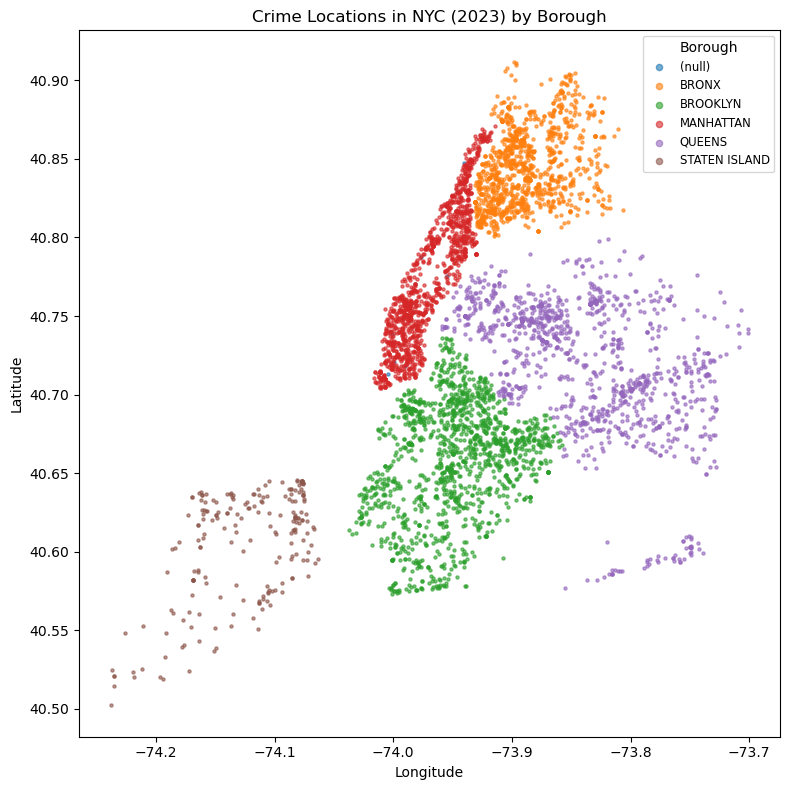

KeyError: 'Offense'

<Figure size 800x500 with 0 Axes>

In [22]:
# Cell 7: Filter 2023 and sample
year = 2023
year_df = df2.withColumn("year", spark_year(col("RPT_DT"))).filter(col("year")==year)
pdf_year = year_df.toPandas().sample(n=5000, random_state=42)

# 2023 scatter by borough
plt.figure(figsize=(8,8))
for borough, group in pdf_year.groupby('BORO_NM'):
    plt.scatter(group['lon'], group['lat'], s=5, alpha=0.6, label=borough)
plt.title("Crime Locations in NYC (2023) by Borough")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(markerscale=2, fontsize='small', title='Borough')
plt.tight_layout()
plt.show()

# Top 10 offenses in 2023
top_offenses = (
    pdf_year["PD_DESC"]
    .value_counts()
    .nlargest(10)
    .reset_index()
    .rename(columns={"index":"Offense", "PD_DESC":"Count"})
)

plt.figure(figsize=(8,5))
plt.bar(top_offenses['Offense'], top_offenses['Count'])
plt.title("Top 10 Offenses in NYC (2023)")
plt.xlabel("Offense")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [23]:
# ┌──────────────────────────────────────────────────────────────┐
# │ Cell X: Prepare pdf_year for a given year (e.g. 2023)       │
# └──────────────────────────────────────────────────────────────┘

from pyspark.sql.functions import to_date, year as spark_year, col

# 1) Parse RPT_DT into DateType if not already done
df2 = df2.withColumn(
    "RPT_DT",
    to_date(col("RPT_DT"), "MM/dd/yyyy")
)

# 2) Extract year, filter for target_year
target_year = 2023
year_df = (
    df2
    .withColumn("year", spark_year(col("RPT_DT")))
    .filter(col("year") == target_year)
)

# 3) Check how many records we have
count_yr = year_df.count()
print(f"Found {count_yr} records for year {target_year}")

# 4) Convert to pandas (only keep needed cols) and sample
pdf_year = (
    year_df
    .select("lat", "lon", "BORO_NM", "PD_DESC")
    .toPandas()
)

# If you want to limit points for plotting:
n_samples = min(len(pdf_year), 5000)
pdf_year = pdf_year.sample(n=n_samples, random_state=42)

print(f"Sampling {n_samples} records for plotting.")
print(pdf_year.head())


Found 554882 records for year 2023


Sampling 5000 records for plotting.
              lat        lon        BORO_NM                         PD_DESC
12476   40.580182 -74.157638  STATEN ISLAND         AGGRAVATED HARASSMENT 2
456265  40.834278 -73.850925          BRONX           LARCENY,GRAND OF AUTO
201113  40.697394 -73.951286       BROOKLYN  IMPERSONATION 2, PUBLIC SERVAN
411329  40.745932 -73.883745         QUEENS                       ASSAULT 3
70288   40.762149 -73.995493      MANHATTAN                RESISTING ARREST


Plotting 114 points for LARCENY,GRAND OF AUTO.


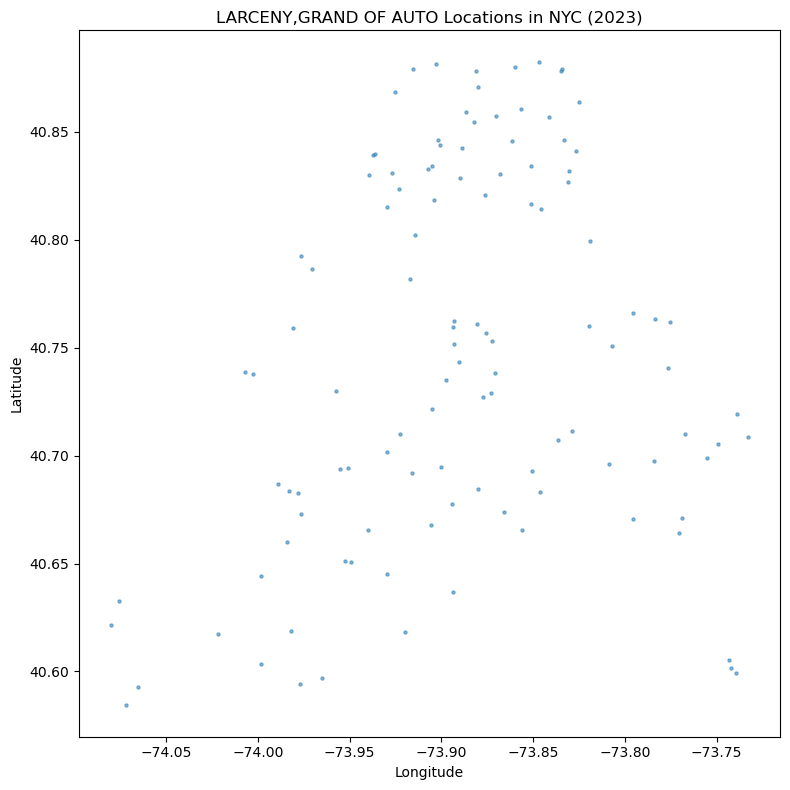

In [26]:
import matplotlib.pyplot as plt

# Use the exact offense string present in pdf_year
offense_name = 'LARCENY,GRAND OF AUTO'

# Filter the DataFrame for that offense
offense_df = pdf_year[pdf_year['PD_DESC'] == offense_name]

if offense_df.empty:
    print(f"No records for offense “{offense_name}” after correction.")
else:
    # Sample up to 2000 points for performance
    sample_n = min(len(offense_df), 2000)
    offense_sample = offense_df.sample(n=sample_n, random_state=1)
    print(f"Plotting {sample_n} points for {offense_name}.")

    # Scatter plot of offense locations
    plt.figure(figsize=(8, 8))
    plt.scatter(
        offense_sample['lon'],    # x: longitude
        offense_sample['lat'],    # y: latitude
        s=5,                      # marker size
        alpha=0.5                 # transparency
    )
    plt.title(f"{offense_name} Locations in NYC (2023)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()
